# CDR3 Graph Analysis

In [ ]:
import sys
import time
from pathlib import Path

import igraph as ig
import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.common.clonotype import Clonotype
from mir.graph.edit_distance_graph import build_edit_distance_graph
from mir.utils.notebook_assets import ensure_airr_benchmark, find_airr_benchmark_vdjdb_slim

In [ ]:
benchmark_root = ensure_airr_benchmark(repo_root, allow_patterns=["vdjdb/**"])
vdjdb_path = find_airr_benchmark_vdjdb_slim(benchmark_root)

vdjdb = pd.read_csv(vdjdb_path, sep='\t')
vdjdb = vdjdb[vdjdb['gene'].eq('TRB')].copy()
print(f'Loaded VDJdb snapshot from: {vdjdb_path}')
print(vdjdb.head())
vdjdb['antigen.epitope'].value_counts().head(20)

  gene              cdr3        species antigen.epitope antigen.gene  \
0  TRB   CASSTSRLSNQPQYF  MacacaMulatta        STPESANL          Tat   
1  TRB   CASSQDRGPANEQFF    HomoSapiens       RLRAEAQVK       EBNA3A   
2  TRB   CASSMSRSSNQPQYF  MacacaMulatta        TTPESANL          Tat   
4  TRB     CASSLGSQNTLYF    MusMusculus       HGIRNASFI          M45   
5  TRB  CSASILGLAGYNEQFF    HomoSapiens       KLGGALQAK          IE1   

  antigen.species                     complex.id       v.segm      j.segm  \
0             SIV                              0    TRBV14*01  TRBJ1-5*01   
1             EBV                          21729   TRBV4-1*01  TRBJ2-1*01   
2             SIV                              0    TRBV14*01  TRBJ1-5*01   
4            MCMV  24797,24785,24840,24778,24833  TRBV12-1*01  TRBJ2-4*01   
5             CMV                          11045  TRBV20-1*01  TRBJ2-1*01   

   v.end  j.start        mhc.a mhc.b mhc.class  \
0      4        8    Mamu-A*01   B2M      MHCI   
1   

antigen.epitope
KLGGALQAK               12667
NLVPMVATV                4697
GILGFVFTL                3501
AVFDRKSDAK               1648
ELAGIGILTV               1422
GLCTLVAML                1044
YLQPRTFLL                 903
RAKFKQLL                  853
IVTDFSVIK                 551
SPRWYFYYL                 543
CTPYDINQM                 530
TTPESANL                  523
KRWIILGLNK                469
TFEYVSQPFLMDLE            445
TTDPSFLGRY                425
RLRAEAQVK                 411
LLWNGPMAV                 409
FRDYVDRFYKTLRAEQASQE      390
PKYVKQNTLKLAT             389
SSYRRPVGI                 345
Name: count, dtype: int64

In [4]:
def get_seqs(epitopes: list[str], size: int = 500, gene: str = 'TRB') -> pd.DataFrame:
    rows = vdjdb[vdjdb['gene'].eq(gene) & vdjdb['antigen.epitope'].isin(epitopes)].copy()
    sampled_parts = []
    for epitope, grp in rows.groupby('antigen.epitope'):
        n_take = min(size, len(grp))
        sampled = grp.sample(n=n_take, random_state=42).copy()
        sampled['antigen.epitope'] = epitope
        sampled_parts.append(sampled)
    if not sampled_parts:
        return pd.DataFrame(columns=['junction_aa', 'antigen.epitope'])
    sampled = pd.concat(sampled_parts, ignore_index=True).drop_duplicates(subset=['cdr3'])
    return sampled[['cdr3', 'antigen.epitope']].rename(columns={'cdr3': 'junction_aa'})

epitopes = ['GLCTLVAML', 'GILGFVFTL', 'NLVPMVATV']
df_epi = get_seqs(epitopes=epitopes, size=1000)
print(df_epi['antigen.epitope'].value_counts())
print('Unique CDR3:', df_epi['junction_aa'].nunique())

antigen.epitope
GILGFVFTL    1000
NLVPMVATV     997
GLCTLVAML     992
Name: count, dtype: int64
Unique CDR3: 2989


In [5]:
clonotypes = [
    Clonotype(
        sequence_id=str(i),
        locus='TRB',
        junction_aa=aa,
        v_gene='TRBV7-9*01',
        j_gene='TRBJ2-1*01',
        duplicate_count=1,
        _validate=False,
    )
    for i, aa in enumerate(df_epi['junction_aa'].tolist())
]

start = time.perf_counter()
g_serial = build_edit_distance_graph(clonotypes, metric='hamming', threshold=1, n_jobs=1)
t_serial = time.perf_counter() - start
print('Serial hamming runtime:', round(t_serial, 3), 's')

start = time.perf_counter()
g_parallel = build_edit_distance_graph(clonotypes, metric='hamming', threshold=1, n_jobs=4)
t_parallel = time.perf_counter() - start
print('Parallel (n_jobs=4) hamming runtime:', round(t_parallel, 3), 's')
if t_parallel > 0:
    print('Speedup:', round(t_serial / t_parallel, 2), 'x')

assert g_serial.ecount() == g_parallel.ecount()
graph = g_parallel
print('Vertices:', graph.vcount(), 'Edges:', graph.ecount())

Serial hamming runtime: 0.017 s
Parallel (n_jobs=4) hamming runtime: 0.017 s
Speedup: 1.03 x
Vertices: 2989 Edges: 633


In [6]:
start = time.perf_counter()
layout = graph.layout_graphopt(niter=2000, node_charge=0.005)
elapsed = time.perf_counter() - start
components = graph.components()
print('Layout runtime:', round(elapsed, 3), 's')
print('Connected components:', len(components))
print('Largest CC size:', max(components.sizes()) if components.sizes() else 0)

Layout runtime: 13.275 s
Connected components: 2584
Largest CC size: 75


In [7]:
coords = pd.DataFrame(layout.coords, columns=['x', 'y'])
df_graph = pd.DataFrame({
    'sequence_id': [str(i) for i in range(graph.vcount())],
    'junction_aa': graph.vs['name'],
    'component_id': graph.components().membership,
    'degree': graph.degree(),
})
df_graph = pd.concat([df_graph, coords], axis=1)
print(df_graph.head())

  sequence_id       junction_aa  component_id  degree            x  \
0           0     CASSTRSGETQYF             0       5  -567.273123   
1           1     CANSIRSTETQYF             0       2  -316.625934   
2           2    CASSVRSGWQPQHF             1       0  1857.836740   
3           3     CASSIRSDNEQFF             2       0  1213.936401   
4           4  CASSLWWRGGTDTQYF             3       0  3065.322001   

             y  
0   507.189149  
1   336.443338  
2 -2089.196332  
3  1054.004725  
4 -2243.381877  


In [8]:
df_graph_summary = (
    df_graph.groupby('component_id', as_index=False)
    .agg(
        cluster_size=('component_id', 'size'),
        x_mean=('x', 'mean'),
        y_mean=('y', 'mean'),
        mean_degree=('degree', 'mean'),
    )
)
print(df_graph_summary.head(10))

   component_id  cluster_size       x_mean       y_mean  mean_degree
0             0            22  -416.506574   502.649697     3.454545
1             1             1  1857.836740 -2089.196332     0.000000
2             2             1  1213.936401  1054.004725     0.000000
3             3             1  3065.322001 -2243.381877     0.000000
4             4             1  2726.504720  2617.421997     0.000000
5             5             1  2628.367444 -1175.335459     0.000000
6             6            75   -29.284528  -453.020672     3.040000
7             7             1  1325.008587 -1067.828160     0.000000
8             8            22   479.499240   136.378865     4.545455
9             9             1  2876.835129  1443.683301     0.000000


In [9]:
df_annot = df_epi.drop_duplicates(subset=['junction_aa'])
df_plot = (
    df_graph.merge(df_graph_summary, on='component_id', how='left')
    .merge(df_annot, on='junction_aa', how='left')
)
print(df_plot.head())

  sequence_id       junction_aa  component_id  degree            x  \
0           0     CASSTRSGETQYF             0       5  -567.273123   
1           1     CANSIRSTETQYF             0       2  -316.625934   
2           2    CASSVRSGWQPQHF             1       0  1857.836740   
3           3     CASSIRSDNEQFF             2       0  1213.936401   
4           4  CASSLWWRGGTDTQYF             3       0  3065.322001   

             y  cluster_size       x_mean       y_mean  mean_degree  \
0   507.189149            22  -416.506574   502.649697     3.454545   
1   336.443338            22  -416.506574   502.649697     3.454545   
2 -2089.196332             1  1857.836740 -2089.196332     0.000000   
3  1054.004725             1  1213.936401  1054.004725     0.000000   
4 -2243.381877             1  3065.322001 -2243.381877     0.000000   

  antigen.epitope  
0       GILGFVFTL  
1       GILGFVFTL  
2       GILGFVFTL  
3       GILGFVFTL  
4       GILGFVFTL  


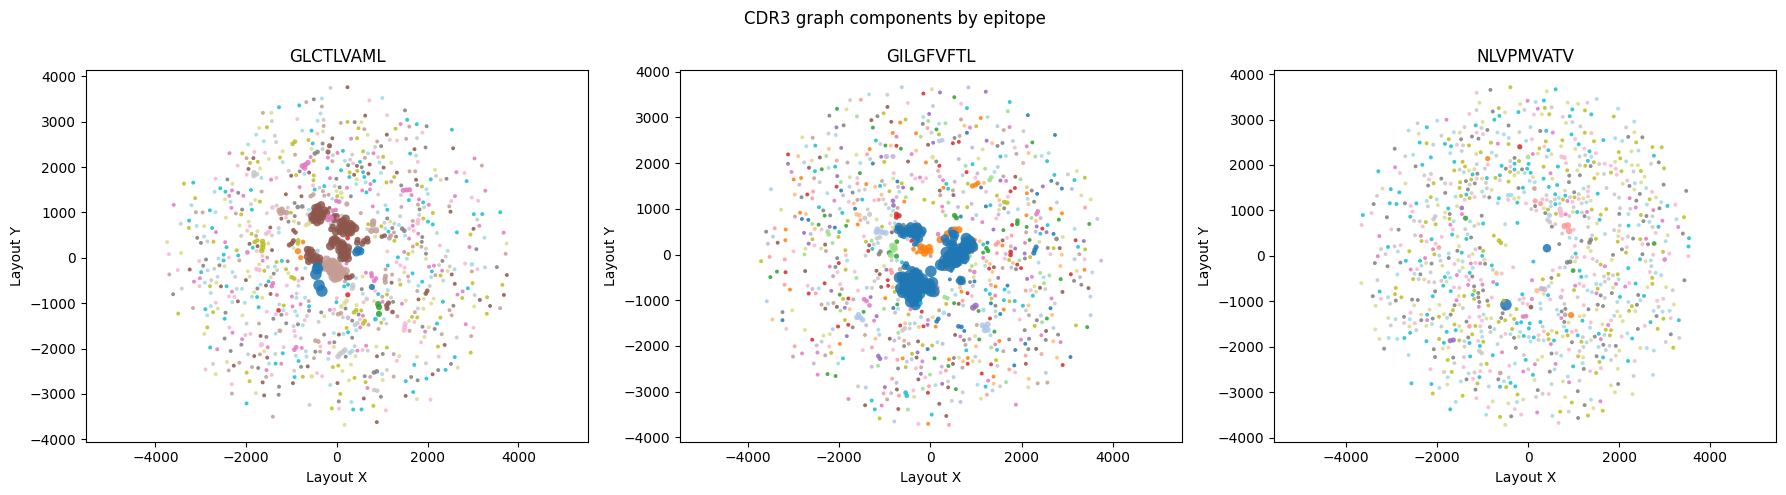

In [10]:
fig, axes = plt.subplots(1, len(epitopes), figsize=(6 * len(epitopes), 5), squeeze=False)
for ax, epitope in zip(axes[0], epitopes):
    sub = df_plot[df_plot['antigen.epitope'].eq(epitope)].copy()
    if sub.empty:
        ax.set_title(f'{epitope} (no data)')
        ax.axis('off')
        continue
    sizes = (sub['cluster_size'].clip(lower=1) ** 0.5) * 8
    sc = ax.scatter(
        sub['x'],
        sub['y'],
        c=sub['component_id'],
        s=sizes,
        cmap='tab20',
        alpha=0.85,
        linewidth=0,
    )
    ax.set_title(epitope)
    ax.set_xlabel('Layout X')
    ax.set_ylabel('Layout Y')
    ax.set_aspect('equal', adjustable='datalim')

fig.suptitle('CDR3 graph components by epitope', fontsize=12)
plt.tight_layout()
plt.show()